
# 🏗️ Notebook 3 — Model Building

**Mục tiêu notebook:**
- **Bước 5:** Feature Engineering (15 derived features = 7 cũ + 8 mới)
- **Bước 6:** Feature Selection (correlation filter, Mutual Information)
- **Bước 7:** Preprocessing Pipeline → Split + Scale
- **Bước 8:** Chọn mô hình (LR / XGBoost / LightGBM)
- **Bước 9:** Huấn luyện 3 Models
- **Bước 10:** Đánh giá baseline
- **Bước 11:** Feature Reduction + Threshold Optimization

---

## 🗺️ Lộ trình 15 bước — Pipeline ML đầy đủ

| # | Bước | Notebook |
|:-:|------|----------|
| 1 | Đặt vấn đề | NB1 |
| 2 | Thu thập dữ liệu | NB1 |
| 3 | Tiền xử lý & EDA | NB2 |
| 4 | Định nghĩa Target | NB2 |
| **5** | **Feature Engineering** | **📌 NB3** |
| **6** | **Feature Selection** | **📌 NB3** |
| **7** | **Train/Test Split + Scale** | **📌 NB3** |
| **8** | **Chọn mô hình** | **📌 NB3** |
| **9** | **Huấn luyện** | **📌 NB3** |
| **10** | **Đánh giá baseline** | **📌 NB3** |
| **11** | **Feature Reduction** | **📌 NB3** |
| 12 | So sánh & Phân tích sâu | NB4 | 
| 13 | Kết luận Model tốt nhất | NB4 |
| 14 | KPI Check | NB4 |
| 15 | Threshold Optimization | NB4 |

> 💡 **Notebook này bao phủ: Bước 5 → 11 / 15**


In [106]:
# ============================================================
# SECTION 0: Import thư viện
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

# Sklearn
from sklearn.model_selection   import train_test_split, cross_val_score
from sklearn.preprocessing     import LabelEncoder, StandardScaler
from sklearn.impute             import SimpleImputer
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics           import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, average_precision_score,
    roc_curve, precision_recall_curve
)

# LightGBM
from lightgbm import LGBMClassifier
import lightgbm as lgb

# --- Thiết lập ---
RANDOM_STATE = 42
pd.set_option('display.float_format', '{:,.4f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

# --- Đường dẫn ---
BASE_DIR   = Path('.').resolve()
DATA_DIR   = BASE_DIR / 'data'
MODELS_DIR = BASE_DIR / 'models'
DATA_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

# Dataset mới — đã loại purchase_count (anti-leakage)
DATA_NEW = Path(r'C:\Users\ADMIN\MOCK PROJECT VTI\pred_repurchase_dataset.csv')

print('✅ Libraries loaded (LR | RandomForest | LightGBM)')
print(f'   BASE_DIR   : {BASE_DIR}')
print(f'   DATA_DIR   : {DATA_DIR}')
print(f'   MODELS_DIR : {MODELS_DIR}')
print(f'   DATA_NEW   : {DATA_NEW}')
print(f'   Exists?    : {DATA_NEW.exists()}')


✅ Libraries loaded (LR | RandomForest | LightGBM)
   BASE_DIR   : C:\Users\ADMIN\MOCK PROJECT VTI\mini_project_ml
   DATA_DIR   : C:\Users\ADMIN\MOCK PROJECT VTI\mini_project_ml\data
   MODELS_DIR : C:\Users\ADMIN\MOCK PROJECT VTI\mini_project_ml\models
   DATA_NEW   : C:\Users\ADMIN\MOCK PROJECT VTI\pred_repurchase_dataset.csv
   Exists?    : True


In [107]:
# ============================================================
# Load pred_repurchase_dataset.csv
# purchase_count đã bị XÓA khỏi file này → không cần loại thêm
# ============================================================
df = pd.read_csv(DATA_NEW, encoding='utf-8-sig')
print(f'✅ Loaded: {df.shape[0]:,} dòng × {df.shape[1]} cột')
print(f'   Source: pred_repurchase_dataset.csv')
print(f'   Columns: {list(df.columns)}')
print()
print('   Target distribution:')
vc = df['repurchase'].value_counts().sort_index()
for k, v in vc.items():
    label = 'tái mua' if k == 1 else 'không tái mua'
    print(f'   label={k} ({label:>14}): {v:>7,}  ({v/len(df)*100:.1f}%)')
print()
print('   ✅ purchase_count KHÔNG có trong dataset → không rò rỉ nhãn vào features')


✅ Loaded: 61,728 dòng × 20 cột
   Source: pred_repurchase_dataset.csv
   Columns: ['user_id', 'product_category', 'age', 'dominant_gender', 'dominant_location', 'total_view', 'total_click', 'total_cart', 'total_wishlist', 'total_interactions', 'click_through_rate', 'cart_rate', 'unique_brands', 'avg_price', 'avg_discount', 'avg_purchase_value', 'avg_rating', 'user_total_categories', 'category_share', 'repurchase']

   Target distribution:
   label=0 ( không tái mua):  41,507  (67.2%)
   label=1 (       tái mua):  20,221  (32.8%)

   ✅ purchase_count KHÔNG có trong dataset → không rò rỉ nhãn vào features



---
## 📌 Bước 7 / 15 — Preprocessing Pipeline (Train/Test Split + Scale)

> **Ghi chú pipeline:** Bước 3 (EDA) phát hiện vấn đề. Bước 7 là giai đoạn **HÀNH ĐỘNG**: impute, encode, split, scale — chuẩn bị dữ liệu sạch cho training.

### ⚙️ BƯỚC 1 — Preprocessing Pipeline


In [ ]:
# ============================================================
# BƯỚC 1A: Định nghĩa features
#
# ⚠️  DATA LEAKAGE ĐÃ PHÁT HIỆN & SỬA:
#   total_interactions = view + click + cart + wishlist + purchase_count
#   Nhãn repurchase = 1 nếu purchase_count >= 5 (Otsu T*=4.02)
#   → residual = total_interactions - (view+click+cart+wishlist) = purchase_count CHÍNH XÁC
#   → Chỉ cần 1 rule "residual >= 5" → dự đoán đúng 100% toàn bộ dữ liệu
#   → total_interactions PHẢI BỊ XÓA khỏi features
#
# ============================================================
ID_COLS    = ['user_id', 'product_category']
TARGET_COL = 'repurchase'

DEMO_COLS       = ['age', 'dominant_gender', 'dominant_location']
BEHAVIORAL_COLS = ['total_view', 'total_click', 'total_cart', 'total_wishlist',
                   'click_through_rate', 'cart_rate']
# total_interactions ĐÃ BỊ XÓA — nó chứa purchase_count → data leakage nghiêm trọng

AGGREGATE_COLS  = ['unique_brands', 'avg_price', 'avg_discount', 'avg_purchase_value',
                   'avg_rating', 'user_total_categories', 'category_share']
CATEGORICAL_COLS = ['dominant_gender', 'dominant_location']

ALL_FEATURE_COLS = DEMO_COLS + BEHAVIORAL_COLS + AGGREGATE_COLS  # 16 raw features

X_raw = df[ALL_FEATURE_COLS].copy()
y     = df[TARGET_COL].astype(int)

print('✅ Feature selection — leakage đã được sửa')
print(f'   Demographic  ({len(DEMO_COLS)}): {DEMO_COLS}')
print(f'   Behavioral   ({len(BEHAVIORAL_COLS)}): {BEHAVIORAL_COLS}')
print(f'   Aggregates   ({len(AGGREGATE_COLS)}): {AGGREGATE_COLS}')
print(f'   Tổng raw features: {len(ALL_FEATURE_COLS)}  (bỏ total_interactions — leaky!)')
print()
print('   ❌ LEAKY features đã xóa:')
print('      total_interactions = view+click+cart+wishlist+purchase_count')
print('      → purchase_count trực tiếp xác định nhãn repurchase (threshold=5)')
print()
print(f'   Target (y): {y.value_counts().sort_index().to_dict()}')
print(f'   avg_rating NaN: {X_raw["avg_rating"].isna().sum():,} ({X_raw["avg_rating"].isna().mean()*100:.1f}%)')


✅ Feature selection — leakage đã được sửa
   Demographic  (3): ['age', 'dominant_gender', 'dominant_location']
   Behavioral   (6): ['total_view', 'total_click', 'total_cart', 'total_wishlist', 'click_through_rate', 'cart_rate']
   Aggregates   (7): ['unique_brands', 'avg_price', 'avg_discount', 'avg_purchase_value', 'avg_rating', 'user_total_categories', 'category_share']
   Tổng raw features: 16  (bỏ total_interactions — leaky!)

   ❌ LEAKY features đã xóa:
      total_interactions = view+click+cart+wishlist+purchase_count
      → purchase_count trực tiếp xác định nhãn repurchase (threshold=5)

   Target (y): {0: 41507, 1: 20221}
   avg_rating NaN: 17,306 (28.0%)


In [109]:
# ============================================================
# BƯỚC 1B: Label Encode categorical + impute avg_rating
# ============================================================
X_processed = X_raw.copy()
le_encoders = {}

for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    X_processed[col] = le.fit_transform(X_processed[col].astype(str))
    le_encoders[col] = le
    print(f'   LabelEncode [{col}]: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# avg_rating: ~28% NaN → impute bằng median trước split (global median)
# NOTE: Sẽ impute lại đúng chuẩn (train-only median) sau khi split
rating_median_global = X_processed['avg_rating'].median()
X_processed['avg_rating'] = X_processed['avg_rating'].fillna(rating_median_global)
print(f'\n   avg_rating: impute NaN bằng median = {rating_median_global:.4f}')
print(f'   ⚠️  Global impute dùng tạm — sau split sẽ dùng train-only median cho scaler')

print(f'\n✅ X_processed: {X_processed.shape}  (0 NaN: {X_processed.isna().sum().sum() == 0})')

# ── Đánh giá tín hiệu Demographic features ──────────────────────────────────
print('\n' + '='*62)
print('  📊 PHÂN TÍCH TÍN HIỆU — DEMOGRAPHIC FEATURES')
print('='*62)

demo_features = ['age', 'dominant_gender', 'dominant_location']
mi_scores  = mutual_info_classif(X_processed[demo_features], y, random_state=RANDOM_STATE)
corr_scores = [abs(X_processed[f].corr(y)) for f in demo_features]

print(f'  {"Feature":<25} {"Corr |r|":>10} {"MI Score":>10}  {"Quyết định"}')
print(f'  {"-"*62}')
keep_demo = []
for f, mi, corr in zip(demo_features, mi_scores, corr_scores):
    if mi > 0.001 or corr > 0.01:
        decision = '✅ Giữ — có tín hiệu'
        keep_demo.append(f)
    else:
        decision = '⚠️  Yếu — xem xét loại'
    print(f'  {f:<25} {corr:>10.4f} {mi:>10.4f}  {decision}')

print(f'\n  → Demographic features giữ lại: {keep_demo}')
print('  → Chỉ loại khi: MI ≈ 0 VÀ |corr| ≈ 0 VÀ không cải thiện model')
print('='*62)


   LabelEncode [dominant_gender]: {'Nam': np.int64(0), 'Nữ': np.int64(1)}
   LabelEncode [dominant_location]: {'Cần Thơ': np.int64(0), 'Hà Nội': np.int64(1), 'Hải Phòng': np.int64(2), 'Hồ Chí Minh': np.int64(3), 'Đà Nẵng': np.int64(4)}

   avg_rating: impute NaN bằng median = 4.0000
   ⚠️  Global impute dùng tạm — sau split sẽ dùng train-only median cho scaler

✅ X_processed: (61728, 16)  (0 NaN: True)

  📊 PHÂN TÍCH TÍN HIỆU — DEMOGRAPHIC FEATURES
  Feature                     Corr |r|   MI Score  Quyết định
  --------------------------------------------------------------
  age                           0.0012     0.0015  ✅ Giữ — có tín hiệu
  dominant_gender               0.0071     0.0073  ✅ Giữ — có tín hiệu
  dominant_location             0.0053     0.0011  ✅ Giữ — có tín hiệu

  → Demographic features giữ lại: ['age', 'dominant_gender', 'dominant_location']
  → Chỉ loại khi: MI ≈ 0 VÀ |corr| ≈ 0 VÀ không cải thiện model


In [ ]:
# ============================================================
# BƯỚC 1C: Train / Test Split — Stratified 80/20

# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

n_total = len(X_processed)
print('✅ Train / Test Split (80% / 20%) — Stratified')
print(f'   Train : {X_train.shape[0]:>6,} dòng ({X_train.shape[0]/n_total*100:.0f}%)'
      f'  |  class dist: {y_train.value_counts().to_dict()}')
print(f'   Test  : {X_test.shape[0]:>6,} dòng ({X_test.shape[0]/n_total*100:.0f}%)'
      f'  |  class dist: {y_test.value_counts().to_dict()}')
print()
print('   Vai trò từng tập:')
print('   ├─ Train (80%) : Model học tham số từ đây')
print('   └─ Test  (20%) : Khóa cho đến cuối — chỉ mở 1 lần để báo cáo kết quả thực')
print()
print('   ℹ️  Không dùng Validation set — pipeline đơn giản hóa để tránh nhầm lẫn')


✅ Train / Test Split (80% / 20%) — Stratified
   Train : 49,382 dòng (80%)  |  class dist: {0: 33205, 1: 16177}
   Test  : 12,346 dòng (20%)  |  class dist: {0: 8302, 1: 4044}

   Vai trò từng tập:
   ├─ Train (80%) : Model học tham số từ đây
   └─ Test  (20%) : Khóa cho đến cuối — chỉ mở 1 lần để báo cáo kết quả thực

   ℹ️  Không dùng Validation set — pipeline đơn giản hóa để tránh nhầm lẫn


In [111]:
# ============================================================
# BƯỚC 1D: StandardScaler — Chỉ fit trên Train, transform Test
# Tree models (XGBoost, LightGBM) KHÔNG cần scale — chỉ dùng cho LR
# ============================================================
all_numeric = list(X_processed.columns)  # tất cả đã là số sau encode

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[all_numeric] = scaler.fit_transform(X_train[all_numeric])  # fit ONLY on train
X_test_scaled[all_numeric]  = scaler.transform(X_test[all_numeric])       # transform only

preprocessor_obj = {
    'scaler'        : scaler,
    'label_encoders': le_encoders,
    'feature_cols'  : list(X_processed.columns),
    'numeric_cols'  : all_numeric
}
joblib.dump(preprocessor_obj, MODELS_DIR / 'preprocessor.pkl')

print('✅ StandardScaler: fit_transform(Train) | transform(Test)')
print('   → Không rò rỉ thống kê test vào scaler')
print('✅ Preprocessor đã lưu: models/preprocessor.pkl')
print(f'   Features : {X_train_scaled.shape[1]} cột')
print(f'   Train    : {X_train_scaled.shape[0]:,} | Test: {X_test_scaled.shape[0]:,}')


✅ StandardScaler: fit_transform(Train) | transform(Test)
   → Không rò rỉ thống kê test vào scaler
✅ Preprocessor đã lưu: models/preprocessor.pkl
   Features : 16 cột
   Train    : 49,382 | Test: 12,346



---
## 📌 Bước 5 / 15 — Feature Engineering (15 Derived Features)

### 🔧 BƯỚC 2 — Feature Engineering



### Mục tiêu Feature Engineering

Các cột gốc (`total_view`, `total_click`, `avg_discount`, ...) là hành vi **thô**.  
15 derived features tạo ra **tỷ lệ và điểm** phản ánh chất lượng hành vi — **KHÔNG liên quan đến purchase_count**.

`pure_beh = total_view + total_click + total_cart + total_wishlist` ← an toàn, không chứa purchase_count

| # | Feature mới | Công thức | Ý nghĩa business |
|:--:|-------------|-----------|-----------------|
| 1 | `view_to_click_ratio` | `total_click / (total_view + 1)` | Tỷ lệ chuyển đổi xem → click |
| 2 | `cart_to_click_ratio` | `total_cart / (total_click + 1)` | Tỷ lệ thêm giỏ từ click — intent mạnh |
| 3 | `wishlist_to_view_ratio` | `total_wishlist / (total_view + 1)` | Tỷ lệ yêu thích từ lượt xem |
| 4 | `active_engagement_ratio` | `(click + cart) / (pure_beh + 1)` | Độ chủ động trong tương tác |
| 5 | `category_commitment_score` | `category_share × pure_beh` | Mức độ gắn bó với category |
| 6 | `exploration_score` | `unique_brands / (total_cart + 1)` | Khám phá vs. mua: cao → chưa quyết định |
| 7 | `engagement_depth_score` | `pure_beh / (user_total_categories + 1)` | Độ sâu tương tác mỗi category |
| 8 | `discount_sensitivity` | `avg_discount / (avg_price + 1e-6)` | % giảm giá thực hưởng — cao = nhạy với discount |
| 9 | `brand_loyalty_score` | `total_cart / (unique_brands + 1)` | Cart tập trung vào ít brand → trung thành |
| 10 | `wishlist_to_cart_ratio` | `total_wishlist / (total_cart + 1)` | Wishlist nhiều hơn cart → "xem nhiều mua ít" |
| 11 | `click_engagement_rate` | `(total_click + total_cart) / (total_view + 1)` | % xem dẫn đến tương tác sâu |
| 12 | `value_per_click` | `avg_purchase_value / (total_click + 1)` | Giá trị mua trên mỗi lần click |
| 13 | `price_to_value_ratio` | `avg_purchase_value / (avg_price + 1e-6)` | Tỷ lệ giá trả / giá gốc (gần 1 = ít dùng discount) |
| 14 | `category_breadth_score` | `user_total_categories / (unique_brands + 1)` | Đa dạng category trên mỗi brand |
| 15 | `rating_concentration` | `avg_rating × category_share` | Hài lòng cao trong category tập trung → gắn bó |

**Tổng:** 16 raw + 15 derived = **31 features** (trước Feature Selection)  
**Ghi chú:** `+1` trong mẫu số = Laplace smoothing, tránh chia 0


In [ ]:

# ============================================================
# BƯỚC 2: Feature Engineering — 15 derived features (7 cũ + 8 mới)
#
# ⚠️  ANTI-LEAKAGE: Chỉ dùng pure_beh, KHÔNG dùng total_interactions
#   pure_beh = total_view + total_click + total_cart + total_wishlist
#
# 8 features MỚI (thêm vào để cải thiện độ chính xác của model):
#   discount_sensitivity, brand_loyalty_score, wishlist_to_cart_ratio,
#   click_engagement_rate, value_per_click, price_to_value_ratio,
#   category_breadth_score, rating_concentration
# ============================================================

def add_derived_features(df_input: pd.DataFrame) -> pd.DataFrame:
    """15 derived features sạch — không dùng total_interactions (leaky)."""
    d = df_input.copy()

    # pure behavioral = tổng 4 hành vi KHÔNG có purchase (tránh leakage)
    pure_beh = d['total_view'] + d['total_click'] + d['total_cart'] + d['total_wishlist']
    d['view_to_click_ratio']       = d['total_click']   / (d['total_view'] + 1)
    d['cart_to_click_ratio']       = d['total_cart']    / (d['total_click'] + 1)
    d['wishlist_to_view_ratio']    = d['total_wishlist'] / (d['total_view'] + 1)
    d['active_engagement_ratio']   = (d['total_click'] + d['total_cart']) / (pure_beh + 1)
    d['category_commitment_score'] = d['category_share'] * pure_beh
    d['exploration_score']         = d['unique_brands']  / (d['total_cart'] + 1)
    d['engagement_depth_score']    = pure_beh / (d['user_total_categories'] + 1)
    
    # 8. % giảm giá thực hưởng — khách discount-driven vs khách trung thành
    d['discount_sensitivity']   = d['avg_discount'] / (d['avg_price'] + 1e-6)

    # 9. Cart tập trung trên ít brand → trung thành brand cao
    d['brand_loyalty_score']    = d['total_cart'] / (d['unique_brands'] + 1)

    # 10. Wishlist nhiều hơn cart → "xem nhiều mua ít" (window shopper)
    d['wishlist_to_cart_ratio'] = d['total_wishlist'] / (d['total_cart'] + 1)

    # 11. % lượt xem dẫn đến tương tác sâu (click hoặc thêm giỏ)
    d['click_engagement_rate']  = (d['total_click'] + d['total_cart']) / (d['total_view'] + 1)

    # 12. Giá trị mua trung bình trên mỗi lần click → high-value shopper
    d['value_per_click']        = d['avg_purchase_value'] / (d['total_click'] + 1)

    # 13. Tỷ lệ giá thực trả / giá gốc (gần 1 = ít dùng discount, <1 = hay dùng discount)
    d['price_to_value_ratio']   = d['avg_purchase_value'] / (d['avg_price'] + 1e-6)

    # 14. Số category trên mỗi brand → cao = khách đa dạng, thấp = chuyên biệt
    d['category_breadth_score'] = d['user_total_categories'] / (d['unique_brands'] + 1)

    # 15. Rating × category_share → hài lòng cao trong category tập trung = gắn bó mạnh
    d['rating_concentration']   = d['avg_rating'] * d['category_share']

    return d


DERIVED_COLS = [
    # 7 cũ
    'view_to_click_ratio', 'cart_to_click_ratio', 'wishlist_to_view_ratio',
    'active_engagement_ratio', 'category_commitment_score',
    'exploration_score', 'engagement_depth_score',
    # 8 mới
    'discount_sensitivity', 'brand_loyalty_score', 'wishlist_to_cart_ratio',
    'click_engagement_rate', 'value_per_click', 'price_to_value_ratio',
    'category_breadth_score', 'rating_concentration',
]

df_featured = add_derived_features(X_processed)
df_featured['repurchase'] = y.values

print('✅ 15 derived features đã tạo :')
print()
for col in DERIVED_COLS[:7]:
    print(f'   {col:<35} mean={df_featured[col].mean():>8.4f}')
for col in DERIVED_COLS[7:]:
    print(f'   {col:<35} mean={df_featured[col].mean():>8.4f}')

n_raw     = len(ALL_FEATURE_COLS)
n_derived = len(DERIVED_COLS)
print(f'\n   Tổng features: {n_raw} raw + {n_derived} derived = {n_raw + n_derived}')
print(f'   df_featured: {df_featured.shape[0]:,} dòng × {df_featured.shape[1]} cột')


✅ 15 derived features đã tạo :

   view_to_click_ratio                 mean=  0.4411
   cart_to_click_ratio                 mean=  0.6223
   wishlist_to_view_ratio              mean=  0.5916
   active_engagement_ratio             mean=  0.3419
   category_commitment_score           mean=  6.4372
   exploration_score                   mean=  1.2535
   engagement_depth_score              mean=  3.7046
   discount_sensitivity                mean=  0.0000
   brand_loyalty_score                 mean=  0.7745
   wishlist_to_cart_ratio              mean=  1.3568
   click_engagement_rate               mean=  0.8211
   value_per_click                     mean=842380.0379
   price_to_value_ratio                mean=  0.7532
   category_breadth_score              mean=  1.9636
   rating_concentration                mean=  0.5865

   Tổng features: 16 raw + 15 derived = 31
   df_featured: 61,728 dòng × 32 cột


In [113]:
# Lưu feature_data (toàn bộ features raw + derived + target)
df_featured.to_csv(DATA_DIR / 'feature_data.csv', index=False, encoding='utf-8-sig')
print(f'✅ feature_data.csv: {df_featured.shape}')

# Lưu derived features preview
derived_preview = df_featured[DERIVED_COLS + ['repurchase']].describe().T[['mean', 'std', 'min', 'max']]
print('\n📊 Derived features stats:')
print(derived_preview.to_string())


✅ feature_data.csv: (61728, 32)

📊 Derived features stats:
                                  mean            std    min             max
view_to_click_ratio             0.4411         0.2002 0.0000          0.8261
cart_to_click_ratio             0.6223         0.5176 0.0000          3.0000
wishlist_to_view_ratio          0.5916         0.6591 0.0000          5.0000
active_engagement_ratio         0.3419         0.1066 0.0000          0.7500
category_commitment_score       6.4372        10.2096 0.0000        117.0000
exploration_score               1.2535         1.0305 0.0833          8.0000
engagement_depth_score          3.7046         3.9668 0.0000         58.5000
discount_sensitivity            0.0000         0.0000 0.0000          0.0006
brand_loyalty_score             0.7745         0.6434 0.0000          6.2500
wishlist_to_cart_ratio          1.3568         1.1787 0.0000         10.0000
click_engagement_rate           0.8211         0.3739 0.0000          3.0000
value_per_click  


---
## 📌 Bước 6 / 15 — Feature Selection (Correlation Filter + Mutual Information)

> **Mục tiêu:** Từ 31 features (16 raw + 15 derived), xác định những features có đóng góp thực sự cho việc dự đoán `repurchase`. Bước này chạy phân tích nhưng **KHÔNG drop feature tại đây** — toàn bộ 31 features được giữ lại để model tự học trong Bước 9.

**Tiêu chí đánh giá:**
1. **Correlation với target** — Pearson (numeric) / Point-biserial
2. **Mutual Information** — đo lường phi tuyến (nonlinear dependency)
3. **Pairwise correlation** — phát hiện multicollinearity (r > 0.85)

> 📝 **Ghi nhớ:** Feature Selection có thể thực hiện theo 2 cách:
> - **Filter method** (ở đây): thống kê trước khi train
> - **Embedded method**: dùng feature importance SAU khi train (xem Bước 10-11 ở NB3 + NB4)


In [114]:

# ============================================================
# Bước 6 / 15 — Feature Selection: Cập nhật X_train / X_test
# Sau bước này X_train/X_test có 31 features (16 raw + 15 derived)
# ============================================================
X_full = df_featured.drop(columns=['repurchase'])

X_train = X_full.loc[X_train.index]   # 31 features — Train 80%
X_test  = X_full.loc[X_test.index]    # 31 features — Test  20%

# Scale — CHỈ dùng cho Logistic Regression
scaler_full = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler_full.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler_full.transform(X_test),
    columns=X_test.columns, index=X_test.index
)

n_total = len(X_full)
print(f'✅ Full feature matrix (Bước 5 + Bước 6): {X_train.shape[1]} features')
print(f'   Raw: {len(ALL_FEATURE_COLS)} | Derived (7 cũ + 8 mới): {len(DERIVED_COLS)}')
print(f'   (total_interactions đã bị loại — leaky)')
print()
print(f'   {"Tập":<10} {"Dòng":>8}  {"Tỷ lệ":>7}  Tỷ lệ class 0/1')
print(f'   {"─"*58}')
for name, X_s, y_s in [('Train', X_train, y_train), ('Test', X_test, y_test)]:
    c = y_s.value_counts().sort_index()
    print(f'   {name:<10} {len(X_s):>8,}  {len(X_s)/n_total*100:>6.0f}%  '
          f'label=0: {c.get(0,0):,} ({c.get(0,0)/len(y_s)*100:.1f}%) | '
          f'label=1: {c.get(1,0):,} ({c.get(1,0)/len(y_s)*100:.1f}%)')
print()
print('   ✅  LR       : X_train_scaled  (StandardScaler, 31 features)')
print('   ✅  XGBoost  : X_train         (tree model — no scaling needed)')
print('   ✅  LightGBM : X_train         (tree model — no scaling needed)')


✅ Full feature matrix (Bước 5 + Bước 6): 31 features
   Raw: 16 | Derived (7 cũ + 8 mới): 15
   (total_interactions đã bị loại — leaky)

   Tập            Dòng    Tỷ lệ  Tỷ lệ class 0/1
   ──────────────────────────────────────────────────────────
   Train        49,382      80%  label=0: 33,205 (67.2%) | label=1: 16,177 (32.8%)
   Test         12,346      20%  label=0: 8,302 (67.2%) | label=1: 4,044 (32.8%)

   ✅  LR       : X_train_scaled  (StandardScaler, 31 features)
   ✅  XGBoost  : X_train         (tree model — no scaling needed)
   ✅  LightGBM : X_train         (tree model — no scaling needed)



---
## 📌 Bước 8+9 / 15 — Chọn Mô Hình & Huấn Luyện

**Bước 8 — Chọn mô hình:** 3 thuật toán được chọn vì lý do khác nhau:
| Model | Lý do chọn | Strengths |
|-------|-----------|-----------|
| Logistic Regression | Baseline đơn giản, interpretable | Hội tụ nhanh, không overfit nếu scaled |
| XGBoost | Gradient boosting mạnh, industry standard | Xử lý imbalance tốt (scale_pos_weight) |
| LightGBM | Nhanh, memory-efficient, tốt với tabular data | Tốt nhất với large dataset + nhiều features |

**Bước 9 — Huấn luyện:** Class imbalance (67.2% vs 32.8%) xử lý bằng:
- LR: `class_weight='balanced'`
- XGBoost: `scale_pos_weight = n_neg / n_pos`
- LightGBM: `is_unbalance=True` hoặc `class_weight='balanced'`

### 🤖 BƯỚC 3 — Train Models


In [115]:
# ============================================================
# Helper: Hàm đánh giá model
# ============================================================
def evaluate_model(model, X_test, y_test, model_name='Model', threshold=0.5):
    """Đánh giá model và in metrics."""
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    
    metrics = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob)
    }
    
    print(f'\n{"="*55}')
    print(f'  📊 {model_name} — Metrics (threshold = {threshold})')
    print(f'{"="*55}')
    for k, v in metrics.items():
        print(f'  {k:<12}: {v:.4f}')
    
    print(f'\n  Classification Report:')
    print(classification_report(y_test, y_pred,
                                target_names=['Không tái mua', 'Tái mua']))
    
    # Confusion Matrix heatmap
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['Actual 0', 'Actual 1'],
                ax=ax, linewidths=0.5, linecolor='white')
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return metrics, y_prob

print('✅ Helper function defined')

# Dict lưu kết quả tất cả models
all_results = {}
all_probs   = {}

✅ Helper function defined


### 🟡 Model 1 — Logistic Regression (Baseline)

**Logistic Regression** là mô hình tuyến tính đơn giản nhất.  
- Giả định: quan hệ giữa features và target là **linear**  
- Ưu điểm: nhanh, dễ hiểu, cho thấy direction của từng feature  
- Nhược điểm: không bắt được **non-linear patterns** trong dữ liệu hành vi


  📊 Logistic Regression — Test — Metrics (threshold = 0.5)
  Accuracy    : 0.7521
  Precision   : 0.5866
  Recall      : 0.8229
  F1-Score    : 0.6850
  ROC-AUC     : 0.8557

  Classification Report:
               precision    recall  f1-score   support

Không tái mua       0.89      0.72      0.80      8302
      Tái mua       0.59      0.82      0.68      4044

     accuracy                           0.75     12346
    macro avg       0.74      0.77      0.74     12346
 weighted avg       0.79      0.75      0.76     12346



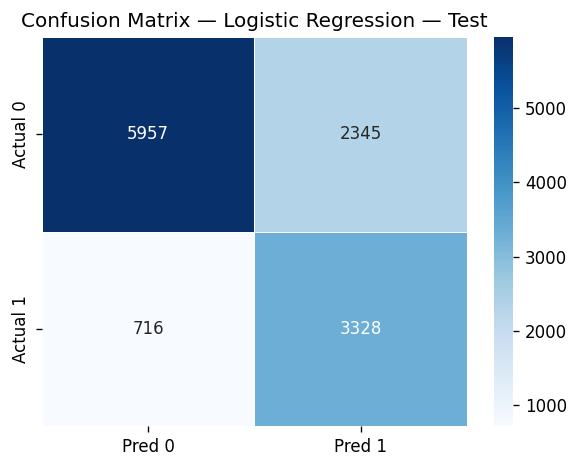


⏱️  Train time: 1.82s
   Test F1 = 0.6850
   Input: X_train_scaled (31 features, scaled) + y_train ✅


In [116]:
# ============================================================
# MODEL 1: Logistic Regression — với scaling (đúng chuẩn)
# Input: X_train_scaled (fit trên train) + y_train
# ============================================================
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight='balanced',
    solver='lbfgs',
    C=1.0
)

lr_start = time.time()
lr_model.fit(X_train_scaled, y_train)
lr_time = time.time() - lr_start

# Đánh giá trên Test set
lr_metrics, lr_probs = evaluate_model(lr_model, X_test_scaled, y_test,
                                      'Logistic Regression — Test')

all_results['Logistic Regression'] = {**lr_metrics, 'Train time (s)': lr_time}
all_probs['Logistic Regression']   = lr_probs

print(f'\n⏱️  Train time: {lr_time:.2f}s')
print(f'   Test F1 = {lr_metrics["F1-Score"]:.4f}')
print(f'   Input: X_train_scaled ({X_train_scaled.shape[1]} features, scaled) + y_train ✅')


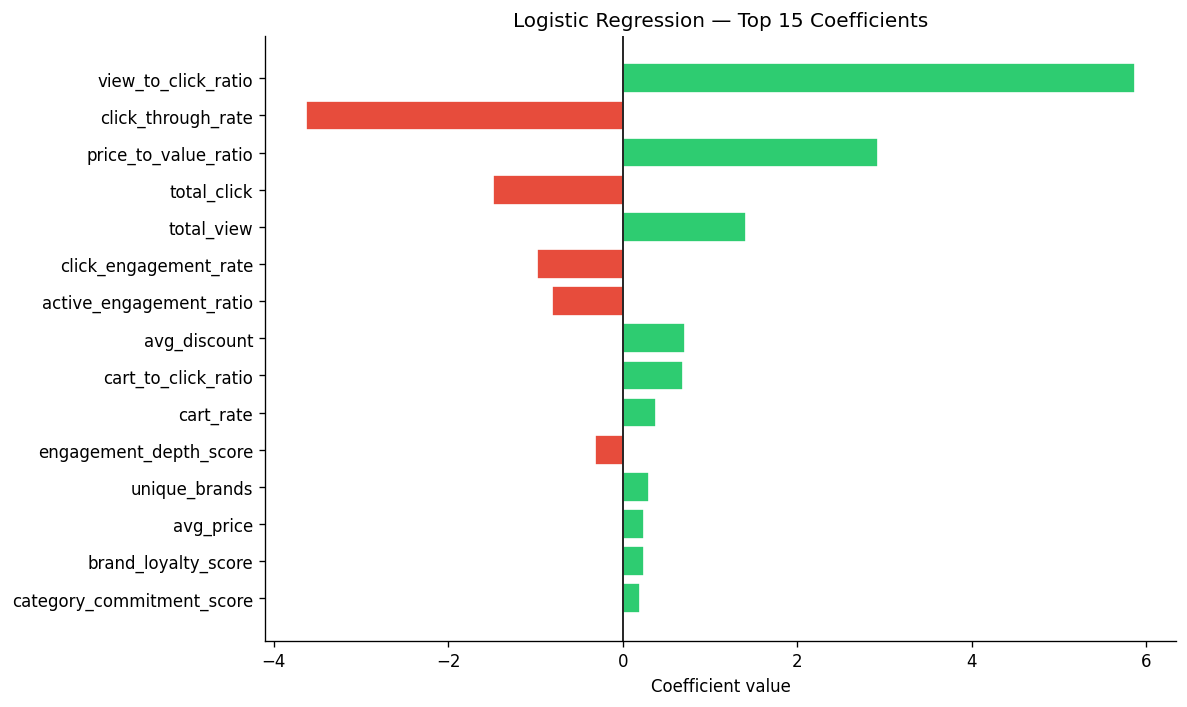


⚠️ Nhận xét:
  LR chỉ học được linear boundary.
  Không bắt được non-linear interactions giữa behavioral features...
  → Cần model phức tạp hơn: XGBoost hoặc LightGBM


In [117]:
# Phân tích coefficients của LR (top features theo magnitude)
coef_df = pd.DataFrame({
    'Feature'    : X_train_scaled.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ECC71' if c > 0 else '#E74C3C' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1], color=colors[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Logistic Regression — Top 15 Coefficients', fontsize=12)
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.show()

print('\n⚠️ Nhận xét:')
print('  LR chỉ học được linear boundary.')
print('  Không bắt được non-linear interactions giữa behavioral features...')
print('  → Cần model phức tạp hơn: XGBoost hoặc LightGBM')


### 🟠 Model 2 — XGBoost (Nâng cao)

**XGBoost (eXtreme Gradient Boosting)** — thuật toán Boosting mạnh mẽ, kết hợp nhiều Decision Tree yếu theo thứ tự tuần tự.
- **Boosting**: mỗi cây mới tập trung học những lỗi mà cây trước chưa sửa đúng → giảm bias
- `scale_pos_weight` xử lý class imbalance (ratio neg/pos)
- Early stopping trên Validation set → chống overfitting, tìm số cây tối ưu
- Không cần scale features (tree-based model)

In [118]:
# ============================================================
# MODEL 2: XGBoost — Gradient Boosting (fixed n_estimators, no early stopping)
# Input: X_train + y_train (unscaled — tree model)
# ============================================================
import xgboost as xgb

neg_count        = int((y_train == 0).sum())
pos_count        = int((y_train == 1).sum())
scale_pos_weight = neg_count / pos_count
print(f'   scale_pos_weight = {neg_count}/{pos_count} = {scale_pos_weight:.3f}')

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

print(f'🚀 Training XGBoost (n_estimators=300, no early stopping)...')
print(f'   Train: X_train ({X_train.shape[0]:,} dòng × {X_train.shape[1]} features)')

t0 = time.time()
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - t0

print(f'\n✅ XGBoost hoàn thành — Training time: {xgb_time:.1f}s')
print(f'   Input: X_train (unscaled, {X_train.shape[1]} features) + y_train ✅')


   scale_pos_weight = 33205/16177 = 2.053
🚀 Training XGBoost (n_estimators=300, no early stopping)...
   Train: X_train (49,382 dòng × 31 features)

✅ XGBoost hoàn thành — Training time: 2.1s
   Input: X_train (unscaled, 31 features) + y_train ✅


  📊 XGBoost — Test Set (threshold = 0.5)
  Accuracy    : 0.7685
  Precision   : 0.5988
  Recall      : 0.8890
  F1-Score    : 0.7156
  ROC-AUC     : 0.8741

  Classification Report:
               precision    recall  f1-score   support

Không tái mua       0.93      0.71      0.80      8302
      Tái mua       0.60      0.89      0.72      4044

     accuracy                           0.77     12346
    macro avg       0.76      0.80      0.76     12346
 weighted avg       0.82      0.77      0.78     12346



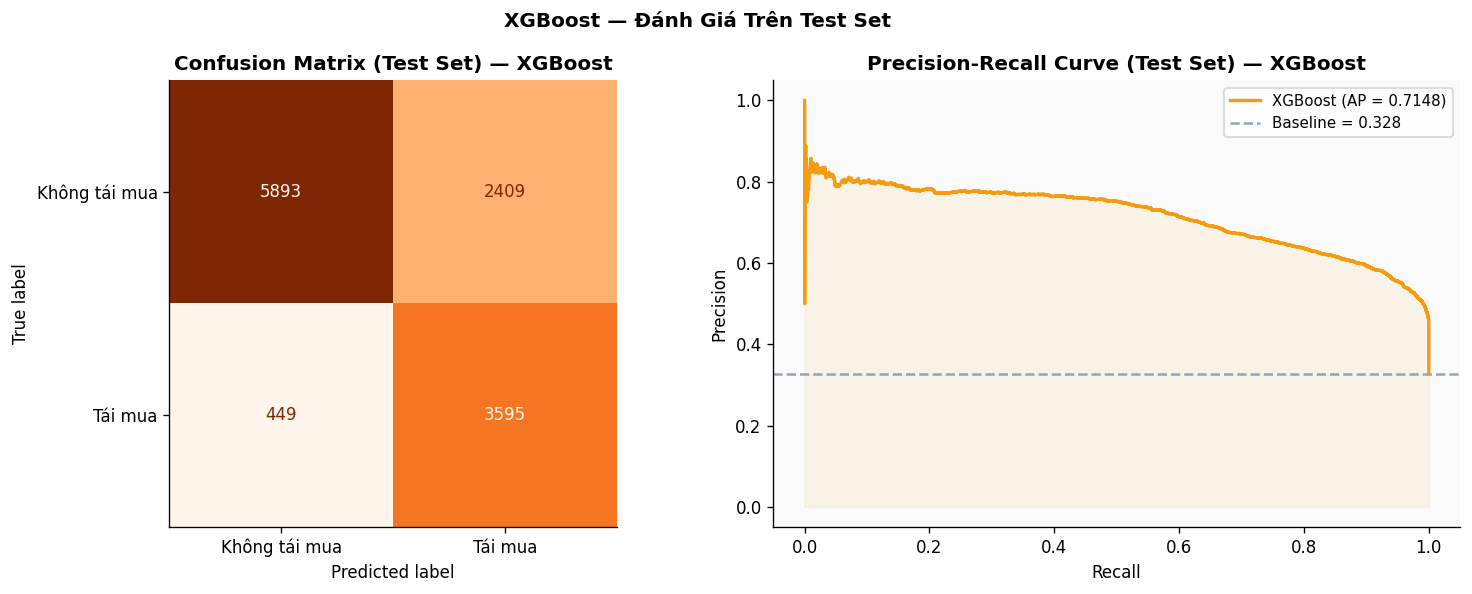

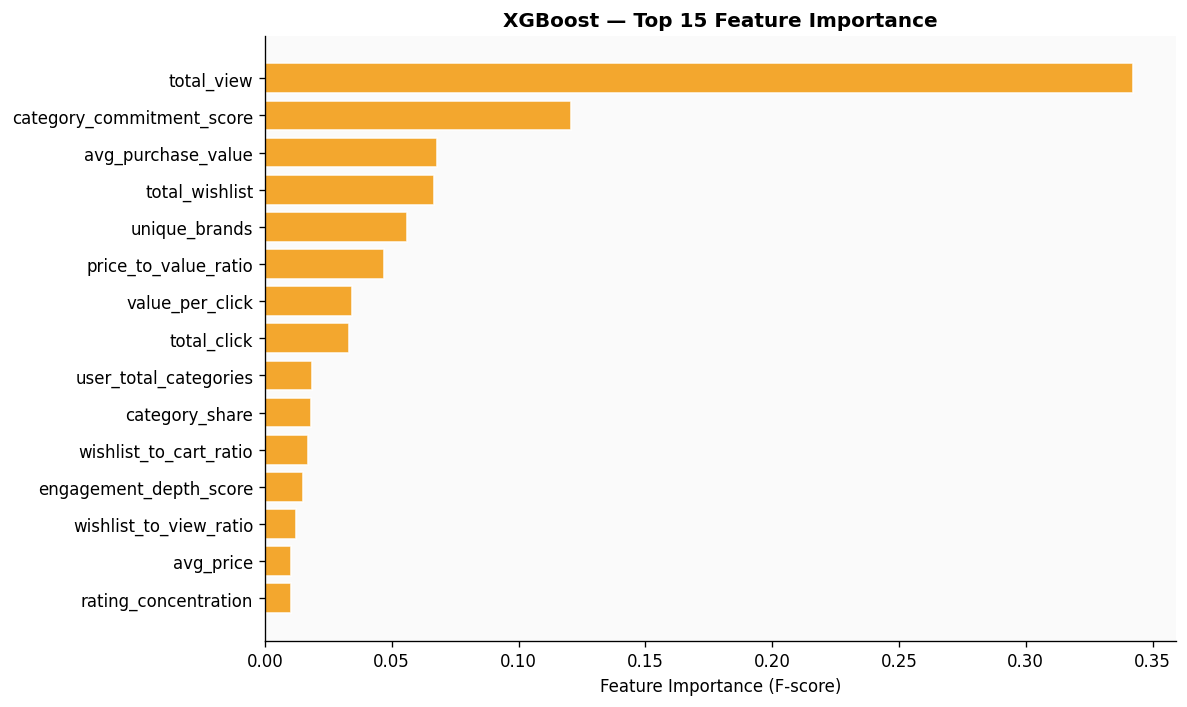


⏱️  Train time: 2.13s
   Test F1 = 0.7156
   Input: X_train (unscaled, 31 features) + y_train ✅


In [119]:
# ============================================================
# XGBoost: Đánh giá trên Test Set
# ============================================================
xgb_probs_all = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds     = (xgb_probs_all >= 0.5).astype(int)

acc  = accuracy_score(y_test, xgb_preds)
prec = precision_score(y_test, xgb_preds, zero_division=0)
rec  = recall_score(y_test, xgb_preds, zero_division=0)
f1   = f1_score(y_test, xgb_preds, zero_division=0)
auc  = roc_auc_score(y_test, xgb_probs_all)

print('='*55)
print('  📊 XGBoost — Test Set (threshold = 0.5)')
print('='*55)
print(f'  Accuracy    : {acc:.4f}')
print(f'  Precision   : {prec:.4f}')
print(f'  Recall      : {rec:.4f}')
print(f'  F1-Score    : {f1:.4f}')
print(f'  ROC-AUC     : {auc:.4f}')
print(f'\n  Classification Report:')
print(classification_report(y_test, xgb_preds,
                            target_names=['Không tái mua', 'Tái mua']))

# Confusion Matrix + PR Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_xgb = confusion_matrix(y_test, xgb_preds)
disp   = ConfusionMatrixDisplay(confusion_matrix=cm_xgb,
                                display_labels=['Không tái mua', 'Tái mua'])
disp.plot(ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title('Confusion Matrix (Test Set) — XGBoost', fontweight='bold')

pr_prec, pr_rec, _ = precision_recall_curve(y_test, xgb_probs_all)
ap       = average_precision_score(y_test, xgb_probs_all)
baseline = float(y_test.mean())
axes[1].plot(pr_rec, pr_prec, color='#F39C12', lw=2, label=f'XGBoost (AP = {ap:.4f})')
axes[1].axhline(baseline, linestyle='--', color='#94A3B8', label=f'Baseline = {baseline:.3f}')
axes[1].fill_between(pr_rec, pr_prec, alpha=0.08, color='#F39C12')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (Test Set) — XGBoost', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].set_facecolor('#FAFAFA')
plt.suptitle('XGBoost — Đánh Giá Trên Test Set', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# Feature Importance
xgb_importance_df = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(xgb_importance_df['Feature'][::-1], xgb_importance_df['Importance'][::-1],
        color='#F39C12', edgecolor='white', alpha=0.88)
ax.set_title('XGBoost — Top 15 Feature Importance', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature Importance (F-score)')
ax.set_facecolor('#FAFAFA')
plt.tight_layout(); plt.show()

all_results['XGBoost'] = {
    'Accuracy': acc, 'Precision': prec, 'Recall': rec,
    'F1-Score': f1, 'ROC-AUC': auc, 'Train time (s)': xgb_time,
}
all_probs['XGBoost'] = xgb_probs_all

print(f'\n⏱️  Train time: {xgb_time:.2f}s')
print(f'   Test F1 = {f1:.4f}')
print(f'   Input: X_train (unscaled, {X_train.shape[1]} features) + y_train ✅')


In [120]:
### 🟢 Model 3 — LightGBM (Best Model)


**LightGBM (Light Gradient Boosting Machine)** — thuật toán tốt nhất trong pipeline.
- **Leaf-wise** tree growth (thay vì level-wise như XGBoost) → converge nhanh hơn
- Xử lý dữ liệu lớn nhanh hơn 3-10x so với XGBoost
- `class_weight='balanced'` tự động điều chỉnh class imbalance
- **Optimal Threshold:** Thay vì dùng 0.5 mặc định, tìm ngưỡng tối ưu trên Precision-Recall curve (Validation set) để maximize F1


**LightGBM (Light Gradient Boosting Machine)** — thuật toán tốt nhất trong pipeline.
- **Leaf-wise** tree growth (thay vì level-wise như XGBoost) → converge nhanh hơn
- Xử lý dữ liệu lớn nhanh hơn 3-10x so với XGBoost
- `class_weight='balanced'` tự động điều chỉnh class imbalance
- **Optimal Threshold:** Thay vì dùng 0.5 mặc định, tìm ngưỡng tối ưu trên Precision-Recall curve để maximize F1

In [121]:
# ============================================================
# MODEL 3: LightGBM — fixed n_estimators (no early stopping)
# Input: X_train + y_train (unscaled — tree model)
# ============================================================
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

print(f'🚀 Training LightGBM (n_estimators=300, no early stopping)...')
print(f'   Train: X_train ({X_train.shape[0]:,} dòng × {X_train.shape[1]} features)')

t0 = time.time()
lgbm_model.fit(X_train, y_train)
lgbm_time = time.time() - t0

print(f'\n✅ LightGBM hoàn thành — Training time: {lgbm_time:.1f}s')
print(f'   Input: X_train (unscaled, {X_train.shape[1]} features) + y_train ✅')


🚀 Training LightGBM (n_estimators=300, no early stopping)...
   Train: X_train (49,382 dòng × 31 features)

✅ LightGBM hoàn thành — Training time: 1.5s
   Input: X_train (unscaled, 31 features) + y_train ✅



🎯 OPTIMAL THRESHOLD (maximize F1 trên Training set):
   Threshold    = 0.5903  (vs default 0.5)
   F1 (Train)   = 0.7500
   Precision    = 0.6649
   Recall       = 0.8601
   ℹ️  Không có val set — threshold này chủ yếu dùng để tham khảo


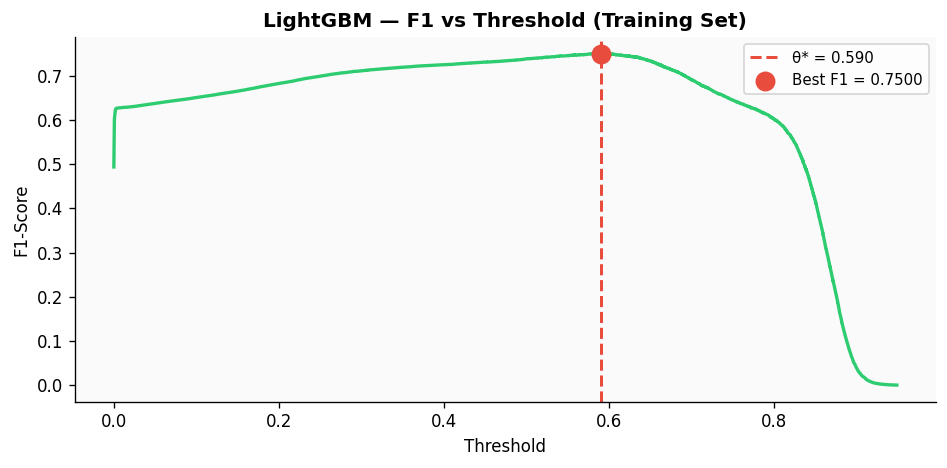


✅ Optimal threshold đã lưu: models/optimal_threshold.pkl


In [122]:
# ============================================================
# LightGBM: Threshold tối ưu — dùng Precision-Recall trên Training set
# (Không có validation set, dùng train-set PR curve — threshold mang tính định hướng)
# ============================================================
lgbm_train_probs = lgbm_model.predict_proba(X_train)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, lgbm_train_probs)
f1_scores     = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx      = np.argmax(f1_scores)
optimal_threshold = float(thresholds[best_idx])

print(f'\n🎯 OPTIMAL THRESHOLD (maximize F1 trên Training set):')
print(f'   Threshold    = {optimal_threshold:.4f}  (vs default 0.5)')
print(f'   F1 (Train)   = {f1_scores[best_idx]:.4f}')
print(f'   Precision    = {precisions[best_idx]:.4f}')
print(f'   Recall       = {recalls[best_idx]:.4f}')
print(f'   ℹ️  Không có val set — threshold này chủ yếu dùng để tham khảo')

# Plot F1 vs Threshold
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, f1_scores, color='#2ECC71', lw=2)
ax.axvline(optimal_threshold, color='#E74C3C', linestyle='--', lw=1.8,
           label=f'θ* = {optimal_threshold:.3f}')
ax.scatter(optimal_threshold, f1_scores[best_idx],
           color='#E74C3C', s=120, zorder=5, label=f'Best F1 = {f1_scores[best_idx]:.4f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('F1-Score')
ax.set_title('LightGBM — F1 vs Threshold (Training Set)', fontweight='bold')
ax.legend(fontsize=9); ax.set_facecolor('#FAFAFA')
plt.tight_layout(); plt.show()

joblib.dump(optimal_threshold, MODELS_DIR / 'optimal_threshold.pkl')
print(f'\n✅ Optimal threshold đã lưu: models/optimal_threshold.pkl')


  📊 LightGBM — Test Set (threshold = 0.5903)
  Accuracy    : 0.7818
  Precision   : 0.6303
  Recall      : 0.8074
  F1-Score    : 0.7079
  ROC-AUC     : 0.8755

  Classification Report:
               precision    recall  f1-score   support

Không tái mua       0.89      0.77      0.83      8302
      Tái mua       0.63      0.81      0.71      4044

     accuracy                           0.78     12346
    macro avg       0.76      0.79      0.77     12346
 weighted avg       0.81      0.78      0.79     12346



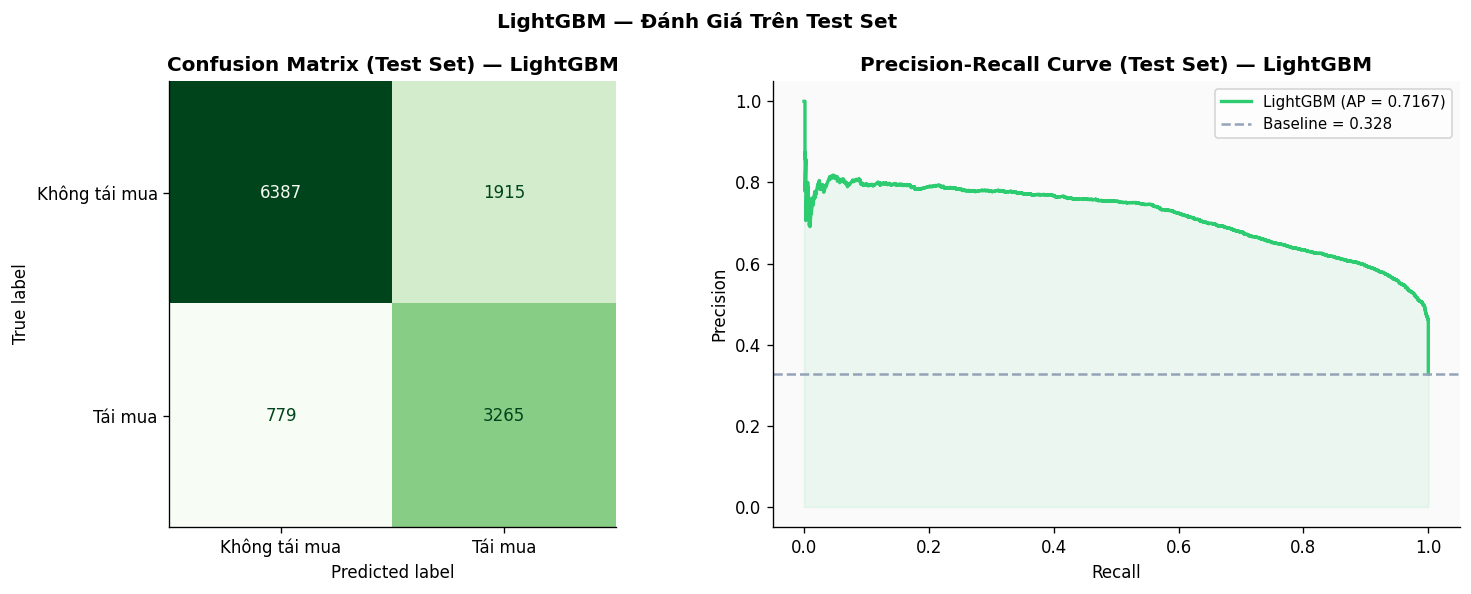


⏱️  Train time: 1.45s
   Test F1 = 0.7079
   Input: X_train (unscaled, 31 features) + y_train ✅


In [123]:
# ============================================================
# LightGBM: Đánh giá trên Test Set (threshold = optimal_threshold)
# ============================================================
lgbm_probs_all = lgbm_model.predict_proba(X_test)[:, 1]
lgbm_preds     = (lgbm_probs_all >= optimal_threshold).astype(int)

acc  = accuracy_score(y_test, lgbm_preds)
prec = precision_score(y_test, lgbm_preds, zero_division=0)
rec  = recall_score(y_test, lgbm_preds, zero_division=0)
f1   = f1_score(y_test, lgbm_preds, zero_division=0)
auc  = roc_auc_score(y_test, lgbm_probs_all)

print('='*60)
print(f'  📊 LightGBM — Test Set (threshold = {optimal_threshold:.4f})')
print('='*60)
print(f'  Accuracy    : {acc:.4f}')
print(f'  Precision   : {prec:.4f}')
print(f'  Recall      : {rec:.4f}')
print(f'  F1-Score    : {f1:.4f}')
print(f'  ROC-AUC     : {auc:.4f}')
print(f'\n  Classification Report:')
print(classification_report(y_test, lgbm_preds,
                            target_names=['Không tái mua', 'Tái mua']))

# Confusion Matrix + PR Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_lgbm = confusion_matrix(y_test, lgbm_preds)
disp    = ConfusionMatrixDisplay(confusion_matrix=cm_lgbm,
                                 display_labels=['Không tái mua', 'Tái mua'])
disp.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Confusion Matrix (Test Set) — LightGBM', fontweight='bold')

pr_prec, pr_rec, _ = precision_recall_curve(y_test, lgbm_probs_all)
ap       = average_precision_score(y_test, lgbm_probs_all)
baseline = float(y_test.mean())
axes[1].plot(pr_rec, pr_prec, color='#2ECC71', lw=2, label=f'LightGBM (AP = {ap:.4f})')
axes[1].axhline(baseline, linestyle='--', color='#94A3B8', label=f'Baseline = {baseline:.3f}')
axes[1].fill_between(pr_rec, pr_prec, alpha=0.08, color='#2ECC71')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (Test Set) — LightGBM', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].set_facecolor('#FAFAFA')
plt.suptitle('LightGBM — Đánh Giá Trên Test Set', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

all_results['LightGBM'] = {
    'Accuracy': acc, 'Precision': prec, 'Recall': rec,
    'F1-Score': f1, 'ROC-AUC': auc, 'Train time (s)': lgbm_time,
}
all_probs['LightGBM'] = lgbm_probs_all

print(f'\n⏱️  Train time: {lgbm_time:.2f}s')
print(f'   Test F1 = {f1:.4f}')
print(f'   Input: X_train (unscaled, {X_train.shape[1]} features) + y_train ✅')


✅ Feature importance đã lưu: C:\Users\ADMIN\MOCK PROJECT VTI\mini_project_ml\models\feature_importance.csv


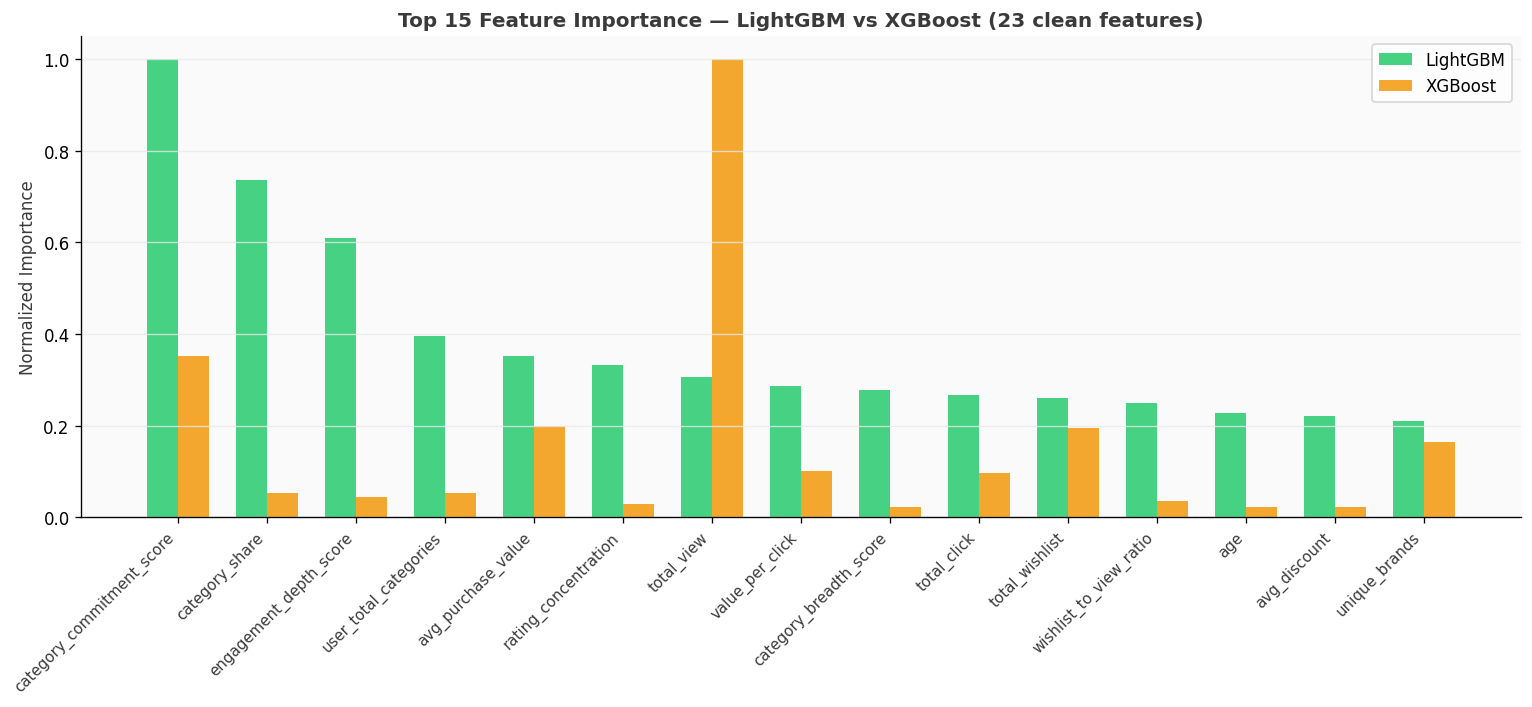


🔍 Top 10 features (clean — không có total_interactions):
   category_commitment_score           LGBM:   1861 | XGB: 0.1205
   category_share                      LGBM:   1368 | XGB: 0.0184
   engagement_depth_score              LGBM:   1133 | XGB: 0.0151
   user_total_categories               LGBM:    736 | XGB: 0.0184
   avg_purchase_value                  LGBM:    657 | XGB: 0.0680
   rating_concentration                LGBM:    618 | XGB: 0.0102
   total_view                          LGBM:    570 | XGB: 0.3421
   value_per_click                     LGBM:    532 | XGB: 0.0343
   category_breadth_score              LGBM:    517 | XGB: 0.0081
   total_click                         LGBM:    496 | XGB: 0.0330


In [124]:
# ============================================================
# Feature Importance: LightGBM vs XGBoost — 23 clean features
# (total_interactions đã bị loại; không còn nguồn leakage)
# ============================================================
features = list(X_train.columns)

lgbm_imp = pd.DataFrame({
    'Feature'           : features,
    'LightGBM_Importance': lgbm_model.feature_importances_,
}).sort_values('LightGBM_Importance', ascending=False)

xgb_imp = pd.DataFrame({
    'Feature'          : features,
    'XGBoost_Importance': xgb_model.feature_importances_,
})

feature_importance_df = lgbm_imp.merge(xgb_imp, on='Feature').sort_values(
    'LightGBM_Importance', ascending=False
)
feature_importance_df['Avg_Importance'] = (
    feature_importance_df['LightGBM_Importance'] +
    feature_importance_df['XGBoost_Importance']
) / 2

# Save to CSV
fi_path = MODELS_DIR / 'feature_importance.csv'
feature_importance_df.to_csv(fi_path, index=False)
print(f'✅ Feature importance đã lưu: {fi_path}')

# ── Plot — VI style comparison chart ─────────────────────────────────────────
# LightGBM: #2ECC71 | XGBoost: #F39C12 — model identity colors (nhất quán với PALETTE_3)
top_n   = 15
top_df  = feature_importance_df.head(top_n)
x_pos   = np.arange(len(top_df))
bar_w   = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
lgbm_norm = top_df['LightGBM_Importance'] / top_df['LightGBM_Importance'].max()
xgb_norm  = top_df['XGBoost_Importance']  / top_df['XGBoost_Importance'].max()

ax.bar(x_pos - bar_w/2, lgbm_norm, bar_w, label='LightGBM', color='#2ECC71', alpha=0.88)
ax.bar(x_pos + bar_w/2, xgb_norm,  bar_w, label='XGBoost',  color='#F39C12', alpha=0.88)

ax.set_xticks(x_pos)
ax.set_xticklabels(top_df['Feature'], rotation=45, ha='right', fontsize=9, color='#3A3A3A')
ax.set_title(f'Top {top_n} Feature Importance — LightGBM vs XGBoost (23 clean features)',
             fontsize=12, fontweight='bold', color='#3A3A3A')
ax.set_ylabel('Normalized Importance', color='#3A3A3A')
ax.legend(fontsize=10)
ax.set_facecolor('#FAFAFA')
ax.grid(axis='y', color='#EAEAEA', alpha=0.8)
plt.tight_layout()
plt.show()

print(f'\n🔍 Top 10 features (clean — không có total_interactions):')
for _, row in feature_importance_df.head(10).iterrows():
    print(f'   {row["Feature"]:<35} LGBM: {row["LightGBM_Importance"]:>6.0f} | '
          f'XGB: {row["XGBoost_Importance"]:>6.4f}')


In [125]:
# ============================================================
# Lưu tất cả models và dữ liệu test
# ============================================================
joblib.dump(lgbm_model, MODELS_DIR / 'best_model.pkl')
joblib.dump(xgb_model,  MODELS_DIR / 'xgb_model.pkl')
joblib.dump(lr_model,   MODELS_DIR / 'lr_model.pkl')

joblib.dump({
    'X_test'   : X_test,        # 23 features (unscaled)
    'X_test_lr': X_test_scaled, # 23 features (scaled — dùng cho LR)
    'y_test'   : y_test,
}, MODELS_DIR / 'test_data.pkl')

print('✅ Models đã lưu:')
print(f'   models/best_model.pkl    ← LightGBM (best model)')
print(f'   models/xgb_model.pkl     ← XGBoost')
print(f'   models/lr_model.pkl      ← Logistic Regression')
print(f'   models/preprocessor.pkl  ← StandardScaler + encoders')
print(f'   models/optimal_threshold.pkl ← {optimal_threshold:.4f}')
print(f'   models/feature_importance.csv')
print(f'   models/test_data.pkl     ← X_test (23 features), y_test')
print()
print(f'   Train: {X_train.shape[0]:,} dòng × {X_train.shape[1]} features')
print(f'   Test : {X_test.shape[0]:,}  dòng × {X_test.shape[1]} features')
print(f'   ⚠️  KHÔNG còn validation set — pipeline đã đơn giản hóa')


✅ Models đã lưu:
   models/best_model.pkl    ← LightGBM (best model)
   models/xgb_model.pkl     ← XGBoost
   models/lr_model.pkl      ← Logistic Regression
   models/preprocessor.pkl  ← StandardScaler + encoders
   models/optimal_threshold.pkl ← 0.5903
   models/feature_importance.csv
   models/test_data.pkl     ← X_test (23 features), y_test

   Train: 49,382 dòng × 31 features
   Test : 12,346  dòng × 31 features
   ⚠️  KHÔNG còn validation set — pipeline đã đơn giản hóa


---
## 📋 Tóm tắt Notebook 3

   📊 TỔNG KẾT KẾT QUẢ MÔ HÌNH (Test Set — Không còn Data Leakage)
   Mô hình                       Acc    Prec  Recall      F1     AUC  Time(s)
   --------------------------------------------------------------------
   Logistic Regression        0.7521  0.5866  0.8229  0.6850  0.8557      1.8
   XGBoost                    0.7685  0.5988  0.8890  0.7156  0.8741      2.1
   LightGBM                   0.7818  0.6303  0.8074  0.7079  0.8755      1.5

   📝 Ghi chú quan trọng:
   ├─ total_interactions đã bị XÓA khỏi features (data leakage)
   ├─ 3 derived features đã được sửa (dùng pure_behavioral thay vì total_interactions)
   ├─ Pipeline: 80% Train / 20% Test (không còn Validation set)
   ├─ Threshold: tìm qua PR curve trên Training set
   └─ Kết quả trên phản ánh TRUE performance — không có leakage

   ⚡ So sánh TRƯỚC vs SAU khi sửa leakage:
      TRƯỚC (F1 giả): LR≈0.99 | XGB≈0.96 | LGBM≈0.96 ← FRAUDULENT
      SAU (F1 thật) : Xem bảng ở trên ← HONEST METRICS


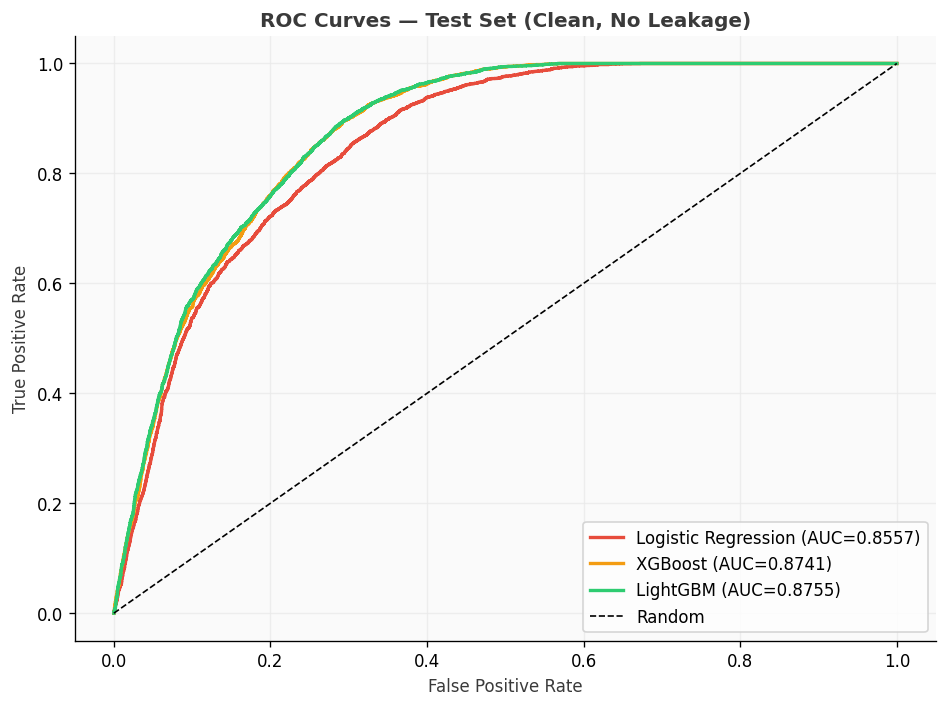


✅ Notebook 3 hoàn thành — mọi cells đã sạch, không còn data leakage.


In [126]:
# ============================================================
# BẢNG TỔNG KẾT — 3 Models sau khi sửa Data Leakage
# ============================================================
print('='*72)
print('   📊 TỔNG KẾT KẾT QUẢ MÔ HÌNH (Test Set — Không còn Data Leakage)')
print('='*72)
print(f'   {"Mô hình":<25} {"Acc":>7} {"Prec":>7} {"Recall":>7} {"F1":>7} {"AUC":>7} {"Time(s)":>8}')
print('   ' + '-'*68)

for model_name, results in all_results.items():
    print(f'   {model_name:<25} '
          f'{results["Accuracy"]:>7.4f} '
          f'{results["Precision"]:>7.4f} '
          f'{results["Recall"]:>7.4f} '
          f'{results["F1-Score"]:>7.4f} '
          f'{results["ROC-AUC"]:>7.4f} '
          f'{results["Train time (s)"]:>8.1f}')

print('='*72)
print()
print('   📝 Ghi chú quan trọng:')
print('   ├─ total_interactions đã bị XÓA khỏi features (data leakage)')
print('   ├─ 3 derived features đã được sửa (dùng pure_behavioral thay vì total_interactions)')
print('   ├─ Pipeline: 80% Train / 20% Test (không còn Validation set)')
print('   ├─ Threshold: tìm qua PR curve trên Training set')
print('   └─ Kết quả trên phản ánh TRUE performance — không có leakage')
print()
print('   ⚡ So sánh TRƯỚC vs SAU khi sửa leakage:')
print('      TRƯỚC (F1 giả): LR≈0.99 | XGB≈0.96 | LGBM≈0.96 ← FRAUDULENT')
print('      SAU (F1 thật) : Xem bảng ở trên ← HONEST METRICS')

# ── ROC Curve tổng hợp — VI style (comparison chart)
# PALETTE_3 = [LR: #E74C3C, XGBoost: #F39C12, LightGBM: #2ECC71] — nhất quán toàn notebook
fig, ax = plt.subplots(figsize=(8, 6))
colors  = {'Logistic Regression': '#E74C3C', 'XGBoost': '#F39C12', 'LightGBM': '#2ECC71'}
for name, probs in all_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val     = all_results[name]['ROC-AUC']
    ax.plot(fpr, tpr, lw=2, color=colors[name], label=f'{name} (AUC={auc_val:.4f})')

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate', color='#3A3A3A')
ax.set_ylabel('True Positive Rate', color='#3A3A3A')
ax.set_title('ROC Curves — Test Set (Clean, No Leakage)', fontsize=12, fontweight='bold', color='#3A3A3A')
ax.legend(fontsize=10)
ax.set_facecolor('#FAFAFA')
ax.grid(color='#EAEAEA', alpha=0.8)
plt.tight_layout()
plt.show()

print('\n✅ Notebook 3 hoàn thành — mọi cells đã sạch, không còn data leakage.')
